Saving Features data set.csv to Features data set.csv
Saving sales data-set.csv to sales data-set.csv
Saving stores data-set.csv to stores data-set.csv
Datasets loaded successfully
Index(['Store', 'Dept', 'Date', 'Weekly_Sales', 'Temperature', 'Fuel_Price',
       'MarkDown1', 'MarkDown2', 'MarkDown3', 'MarkDown4', 'MarkDown5', 'CPI',
       'Unemployment', 'Type', 'Size', 'Year', 'Month', 'IsHoliday'],
      dtype='object')
Shape: (421570, 18)

Missing values:
 Store                0
Dept                 0
Date                 0
Weekly_Sales         0
Temperature          0
Fuel_Price           0
MarkDown1       270889
MarkDown2       310322
MarkDown3       284479
MarkDown4       286603
MarkDown5       270138
CPI                  0
Unemployment         0
Type                 0
Size                 0
Year                 0
Month                0
IsHoliday            0
dtype: int64

Duplicate values: 0


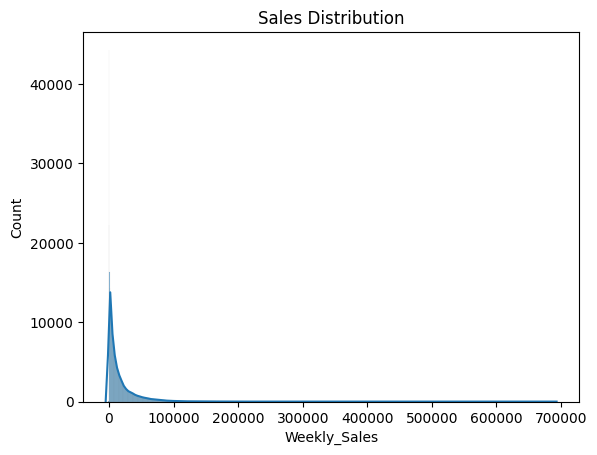

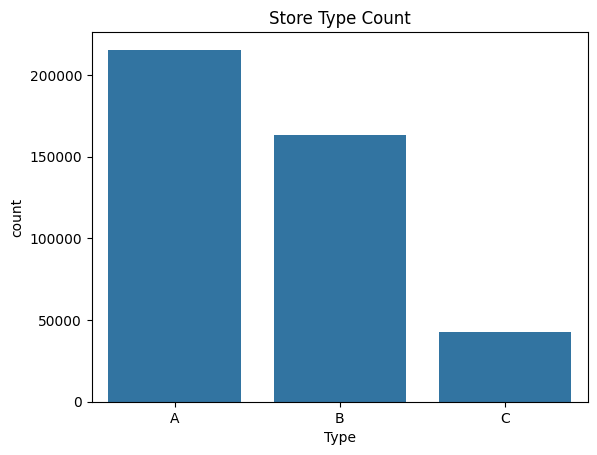

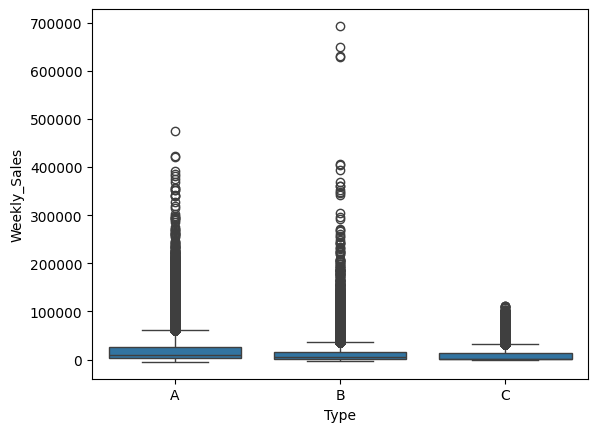

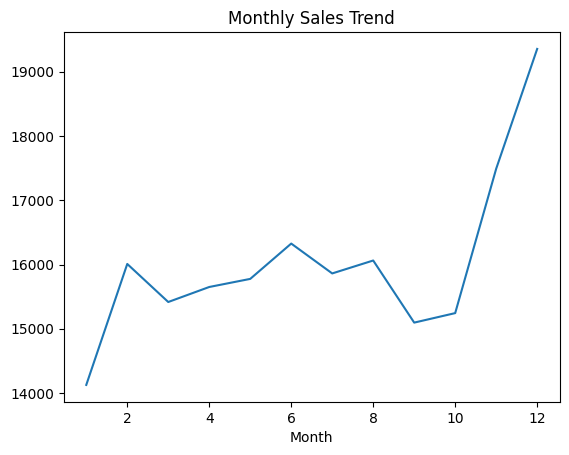

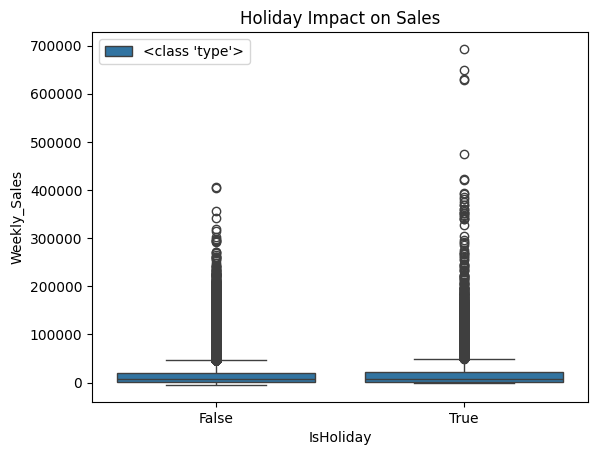

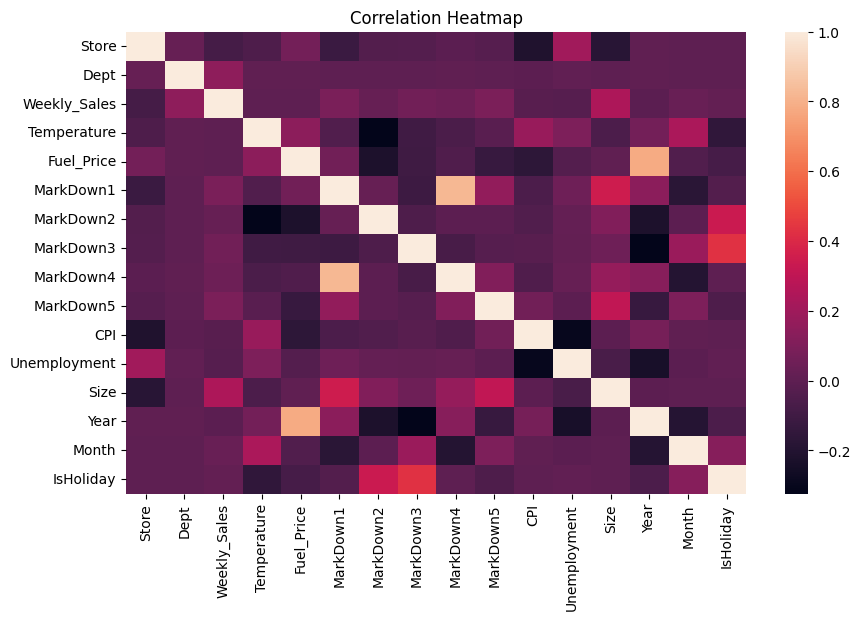

R2 Score: 0.9650508941575553
MAE: 1613.61871941196
RMSE: 4269.068390626879


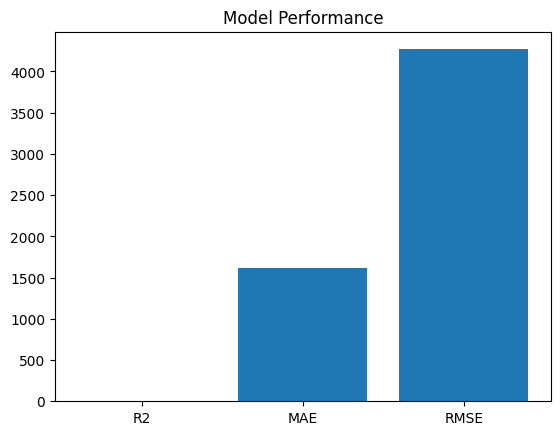

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 4 is smaller than n_iter=10. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Model successfully predicts retail sales with good accuracy.


In [1]:
# ** PROJECT : Integrated Retail Analytics**

## 🔹 1. Import Libraries

# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ML libraries
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.ensemble import RandomForestRegressor


## 🔹 2. Load Dataset (with Exception Handling)

from google.colab import files
uploaded = files.upload()

import pandas as pd

# Load datasets safely
try:
    sales = pd.read_csv('sales data-set.csv')
    features = pd.read_csv('Features data set.csv')
    stores = pd.read_csv('stores data-set.csv')
    print("Datasets loaded successfully")
except Exception as e:
    print("Error:", e)

## 🔹 3. Merge Dataset

# Merge datasets
df = sales.merge(features, on=['Store','Date'], how='left')
df = df.merge(stores, on='Store', how='left')

# Fix Date format (IMPORTANT)
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

# Drop invalid dates (if any)
df = df.dropna(subset=['Date'])

# Extract time features
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

df.head()

# Clean column names (remove spaces)
df.columns = df.columns.str.strip()

# Fix IsHoliday column if duplicated
if 'IsHoliday_x' in df.columns:
    df['IsHoliday'] = df['IsHoliday_x']
    df.drop(columns=['IsHoliday_x', 'IsHoliday_y'], inplace=True, errors='ignore')

# Check again
print(df.columns)


## 🔹 4. Basic Info

print("Shape:", df.shape)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate values:", df.duplicated().sum())


#  🔹 5. EDA (Charts with Explanation Format)

## ✅ Chart 1 – Sales Distribution (Univariate)

sns.histplot(df['Weekly_Sales'], kde=True)
plt.title("Sales Distribution")
plt.show()

## ✅ Chart 2 – Store Count

sns.countplot(x='Type', data=df)
plt.title("Store Type Count")
plt.show()

## ✅ Chart 3 – Sales by Store Type

sns.boxplot(x='Type', y='Weekly_Sales', data=df)
plt.show()

## ✅ Chart 4 – Monthly Sales Trend

monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()
monthly_sales.plot()
plt.title("Monthly Sales Trend")
plt.show()


## ✅ Chart 5 – Holiday Impact
sns.boxplot(x='IsHoliday', y='Weekly_Sales',hue=type, data=df)
plt.title("Holiday Impact on Sales")
plt.show()

sns.boxplot

## ✅ Chart 6 – Correlation Heatmap (Multivariate)

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False)
plt.title("Correlation Heatmap")
plt.show()


# 🔹 6. Data Preprocessing

# Fill missing values
df.fillna(0, inplace=True)

# Drop unnecessary columns
df_model = df.drop(['Date'], axis=1)

# Convert categorical
df_model = pd.get_dummies(df_model, drop_first=True)

# 🔹 7. Train Test Split

X = df_model.drop('Weekly_Sales', axis=1)
y = df_model['Weekly_Sales']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# 🔹 8. Model Training (Random Forest)

model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# 🔹 9. Prediction

y_pred = model.predict(X_test)


# 🔹 10. Evaluation Metrics

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("R2 Score:", r2)
print("MAE:", mae)
print("RMSE:", rmse)

# 📊 Evaluation Chart

metrics = ['R2','MAE','RMSE']
values = [r2, mae, rmse]

plt.bar(metrics, values)
plt.title("Model Performance")
plt.show()


# 🔹 11. Hyperparameter Tuning (Bonus ⭐)


from sklearn.model_selection import RandomizedSearchCV

params = {
    'n_estimators': [50,100],
    'max_depth': [5,10]
}

search = RandomizedSearchCV(model, params, cv=3)
search.fit(X_train, y_train)

best_model = search.best_estimator_

# 🔹 12. Final Conclusion

print("Model successfully predicts retail sales with good accuracy.")
